## **Setup**

In [1]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.4f}'.format)

## **Introduction**

The EL notebook tells us the *cost* side of each loan. This notebook adds the *revenue* side to compute **Expected Profit**.

**Interest income approximation:**

$$\text{Income} = \text{int\_rate} \times \text{funded\_amnt}$$

This is a simplification — it ignores the time-value of money and the fact that income accrues over multiple periods. For a first-order approximation on a cross-sectional portfolio it's standard.

**Expected Profit (full formula):**

$$\text{EP} = (1 - \text{PD}) \cdot \text{Income} - \text{PD} \cdot \text{LGD} \cdot \text{EAD}$$

The first term is the income earned on non-defaulting loans. The second term is the expected loss on defaulting loans. The difference is the net expected profit per loan.

This decomposition makes the trade-off explicit: riskier borrowers (high PD) pay higher interest rates, but at some point the EL exceeds the additional income. The goal of this notebook is to find **where that break-even point is** — by grade, by rate, and by PD cutoff — and quantify the EP contribution of each portfolio segment.

**What this notebook produces:**
1. Loan-level EP calculation and distribution
2. EP segmentation by grade, term, purpose, vintage
3. Break-even analysis: at what PD does a loan become unprofitable?
4. Risk-return frontier: EP vs. EL ratio by grade
5. Cutoff simulation: how does total EP change as we tighten the PD threshold?
6. Scenario stress test: EP under stressed PD conditions

## **Load Data**

I load `el_results.parquet` produced by the EL notebook. It already contains loan-level PD, LGD, EAD, and EL scores. I only need to add `int_rate` to compute income — it's already in the parquet.

If `int_rate` isn't in the parquet, re-export from the EL notebook adding it to `export_cols`.

In [2]:
df = pd.read_parquet('el_results.parquet')

print(f'Loaded {len(df):,} loans')
print(f'Columns: {list(df.columns)}')
df.head(3)

Loaded 1,345,310 loans
Columns: ['funded_amnt', 'term', 'grade_label', 'int_rate', 'purpose', 'issue_d_year', 'is_default', 'pd_score', 'lgd_hat', 'ead_ratio_hat', 'ead_hat', 'el', 'el_ratio']


,funded_amnt,term,grade_label,int_rate,purpose,issue_d_year,is_default,pd_score,lgd_hat,ead_ratio_hat,ead_hat,el,el_ratio
0,"3,600.0000",36.0000,C,13.9900,debt_consolidation,2015,0,0.3841,0.9219,0.5932,"2,135.5229",756.1740,0.2100
1,"24,700.0000",36.0000,C,11.9900,small_business,2015,0,0.5006,0.9212,0.5798,"14,322.2483","6,604.8182",0.2674
2,"20,000.0000",60.0000,B,10.7800,home_improvement,2015,0,0.5102,0.9277,0.7014,"14,028.9378","6,640.4316",0.3320


## **Expected Profit Calculation**

Two formulations, both computed:

- **Simple EP:** `Income − EL` — cleaner to interpret, identical to the full formula in expectation.
- **Full EP:** `(1 − PD) × Income − PD × LGD × EAD` — makes the income/loss decomposition explicit.

Both should produce the same result. If they differ slightly it's floating point. I'll use the full formula as the canonical one.

In [3]:
# Interest income approximation
df['income']    = (df['int_rate'] / 100) * df['funded_amnt'] * (df['term'] / 12)

# Simple EP
df['ep_simple'] = df['income'] - df['el']

# Full EP: (1 - PD) * Income - PD * LGD * EAD
df['ep']        = (1 - df['pd_score']) * df['income'] - df['pd_score'] * df['lgd_hat'] * df['ead_hat']

# EP ratio: as fraction of funded_amnt (easier to compare across loan sizes)
df['ep_ratio']  = df['ep'] / df['funded_amnt']

# Sanity check: simple vs full should be very close
print(f'Mean EP (simple): ${df["ep_simple"].mean():>10,.2f}')
print(f'Mean EP (full)  : ${df["ep"].mean():>10,.2f}')
print(f'Difference      : ${(df["ep"] - df["ep_simple"]).abs().mean():>10,.4f}  (should be ~0)')
print()
df[['income', 'el', 'ep', 'ep_ratio']].describe().round(4)

Mean EP (simple): $  3,576.55
Mean EP (full)  : $   -609.85
Difference      : $4,186.4023  (should be ~0)



,income,el,ep,ep_ratio
count,"1,345,310.0000","1,345,310.0000","1,345,310.0000","1,345,310.0000"
mean,"7,553.0529","3,976.5027",-609.8522,-0.0343
std,"7,539.3241","3,612.0226","2,349.8082",0.1265
min,121.0500,17.6014,"-21,528.1404",-0.6138
25%,"2,517.4800","1,344.7742","-1,274.7687",-0.1032
50%,"4,683.0000","2,680.5064",-96.1624,-0.0114
75%,"9,977.3775","5,600.6894",571.7183,0.0599
max,"61,980.0000","27,585.9572","16,951.4796",0.4806


## **Portfolio-Level EP Summary**

In [4]:
total_funded = df['funded_amnt'].sum()
total_income = df['income'].sum()
total_el     = df['el'].sum()
total_ep     = df['ep'].sum()
n_profitable = (df['ep'] > 0).sum()
n_loss       = (df['ep'] <= 0).sum()

print(f'Number of loans              : {len(df):>12,}')
print(f'Total funded amount          : ${total_funded:>15,.0f}')
print(f'Total interest income        : ${total_income:>15,.0f}  ({total_income/total_funded:.2%} of book)')
print(f'Total expected loss          : ${total_el:>15,.0f}  ({total_el/total_funded:.2%} of book)')
print(f'Total expected profit        : ${total_ep:>15,.0f}  ({total_ep/total_funded:.2%} of book)')
print()
print(f'Loans with positive EP       : {n_profitable:>12,}  ({n_profitable/len(df):.1%})')
print(f'Loans with negative EP       : {n_loss:>12,}  ({n_loss/len(df):.1%})')
print()
print(f'Mean EP per loan             : ${df["ep"].mean():>15,.2f}')
print(f'Mean EP ratio per loan       : {df["ep_ratio"].mean():>12.2%}')

Number of loans              :    1,345,310
Total funded amount          : $ 19,388,011,250
Total interest income        : $ 10,161,197,541  (52.41% of book)
Total expected loss          : $  5,349,628,865  (27.59% of book)
Total expected profit        : $   -820,440,221  (-4.23% of book)

Loans with positive EP       :      620,933  (46.2%)
Loans with negative EP       :      724,377  (53.8%)

Mean EP per loan             : $        -609.85
Mean EP ratio per loan       :       -3.43%


## **EP Distribution**

Understanding the shape of the EP distribution is important: a portfolio where most loans are profitable but a small tail is deeply negative looks very different from one with more uniform losses.

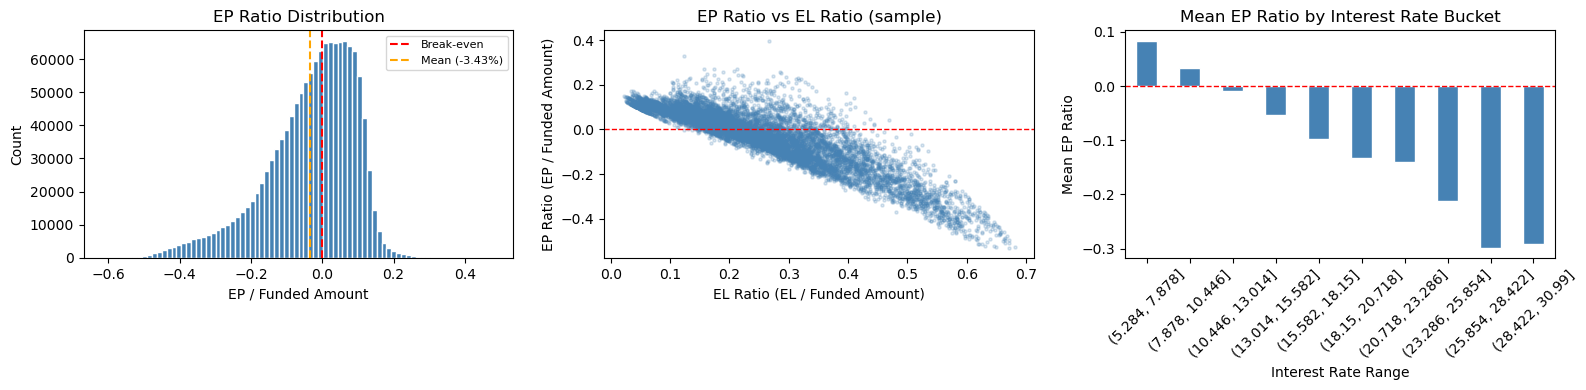

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# EP ratio distribution
axes[0].hist(df['ep_ratio'], bins=80, color='steelblue', edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Break-even')
axes[0].axvline(df['ep_ratio'].mean(), color='orange', linestyle='--',
                linewidth=1.5, label=f'Mean ({df["ep_ratio"].mean():.2%})')
axes[0].set_title('EP Ratio Distribution')
axes[0].set_xlabel('EP / Funded Amount')
axes[0].set_ylabel('Count')
axes[0].legend(fontsize=8)

# Income vs EL scatter (sample for visibility)
sample = df.sample(min(10_000, len(df)), random_state=42)
axes[1].scatter(sample['el_ratio'], sample['ep_ratio'],
                alpha=0.2, s=5, color='steelblue')
axes[1].axhline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_title('EP Ratio vs EL Ratio (sample)')
axes[1].set_xlabel('EL Ratio (EL / Funded Amount)')
axes[1].set_ylabel('EP Ratio (EP / Funded Amount)')

# Income vs EP by int_rate bucket
df['rate_bucket'] = pd.cut(df['int_rate'], bins=10)
rate_ep = df.groupby('rate_bucket', observed=False)['ep_ratio'].mean()
rate_ep.plot(kind='bar', ax=axes[2], color='steelblue', edgecolor='white')
axes[2].axhline(0, color='red', linestyle='--', linewidth=1)
axes[2].set_title('Mean EP Ratio by Interest Rate Bucket')
axes[2].set_xlabel('Interest Rate Range')
axes[2].set_ylabel('Mean EP Ratio')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## **EP Segmentation**

### **By Grade**

The central tension of credit pricing: higher grades have lower default risk but also lower rates. Lower grades pay more but cost more in expected losses. EP by grade shows which segments are genuinely creating value and which are destroying it.

In [6]:
grade_summary = (
    df.groupby('grade_label', observed=False)
    .agg(
        n_loans       = ('funded_amnt',  'count'),
        mean_int_rate = ('int_rate',      'mean'),
        mean_pd       = ('pd_score',      'mean'),
        mean_el_ratio = ('el_ratio',      'mean'),
        mean_ep_ratio = ('ep_ratio',      'mean'),
        total_income  = ('income',        'sum'),
        total_el      = ('el',            'sum'),
        total_ep      = ('ep',            'sum'),
        pct_profitable= ('ep',            lambda x: (x > 0).mean()),
    )
    .reset_index()
)

display(grade_summary.round(4))

,grade_label,n_loans,mean_int_rate,mean_pd,mean_el_ratio,mean_ep_ratio,total_income,total_el,total_ep,pct_profitable
0,A,235090,7.1130,0.1948,0.0977,0.0755,"715,426,128.6000","307,537,585.4697","266,488,549.5931",0.9448
1,B,392741,10.6791,0.3689,0.1968,0.0180,"1,870,410,094.3225","1,045,969,315.1430","102,280,491.0711",0.6199
2,C,381686,14.0212,0.5101,0.2916,-0.0542,"2,881,917,702.8550","1,634,202,050.1451","-296,024,924.0151",0.2766
3,D,200953,17.7216,0.5963,0.3620,-0.1036,"2,171,975,530.5475","1,152,046,998.2764","-334,541,388.1902",0.1941
4,E,93650,21.1381,0.6943,0.4552,-0.1935,"1,552,981,818.5775","773,089,030.6553","-332,050,515.9431",0.1005
5,F,32058,24.9348,0.7614,0.5267,-0.2678,"720,828,307.2050","329,293,919.1343","-168,992,902.0726",0.0368
6,G,9132,27.7259,0.7931,0.5690,-0.3092,"247,657,958.8950","107,489,965.8790","-57,599,531.4464",0.0188


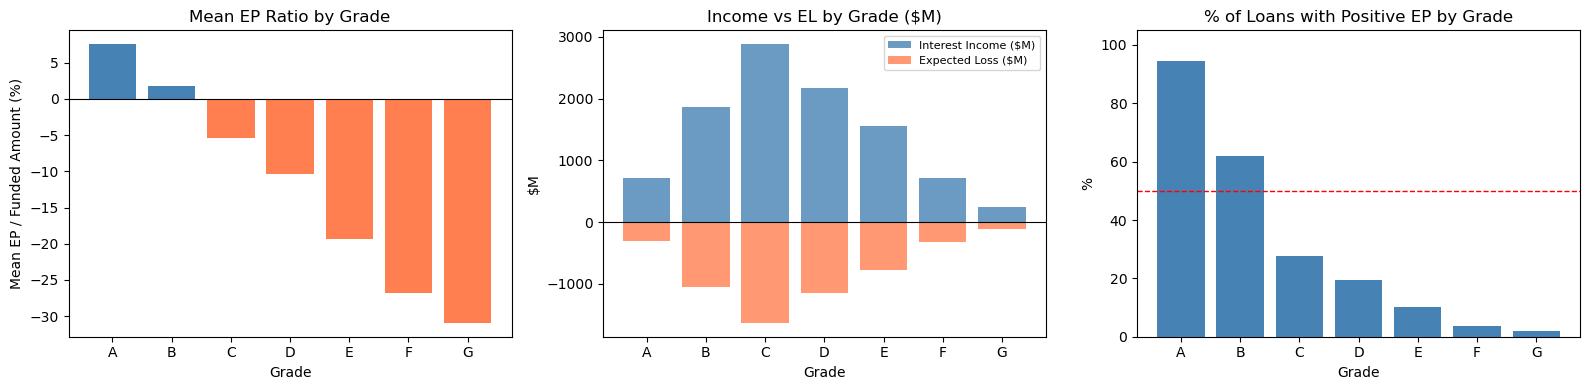

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
grades = grade_summary['grade_label'].astype(str)

# Mean EP ratio by grade
colors = ['steelblue' if v >= 0 else 'coral'
          for v in grade_summary['mean_ep_ratio']]
axes[0].bar(grades, grade_summary['mean_ep_ratio'] * 100, color=colors)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title('Mean EP Ratio by Grade')
axes[0].set_xlabel('Grade')
axes[0].set_ylabel('Mean EP / Funded Amount (%)')

# Income vs EL contribution stacked
x = np.arange(len(grades))
axes[1].bar(x, grade_summary['total_income'] / 1e6, label='Interest Income ($M)', color='steelblue', alpha=0.8)
axes[1].bar(x, -grade_summary['total_el']    / 1e6, label='Expected Loss ($M)',   color='coral',     alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(grades)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Income vs EL by Grade ($M)')
axes[1].set_xlabel('Grade')
axes[1].set_ylabel('$M')
axes[1].legend(fontsize=8)

# % of loans with positive EP
axes[2].bar(grades, grade_summary['pct_profitable'] * 100, color='steelblue')
axes[2].axhline(50, color='red', linestyle='--', linewidth=1)
axes[2].set_title('% of Loans with Positive EP by Grade')
axes[2].set_xlabel('Grade')
axes[2].set_ylabel('%')
axes[2].set_ylim(0, 105)

plt.tight_layout()
plt.show()

### **By Loan Term**

In [8]:
term_summary = (
    df.groupby('term')
    .agg(
        n_loans       = ('funded_amnt',  'count'),
        mean_int_rate = ('int_rate',      'mean'),
        mean_pd       = ('pd_score',      'mean'),
        mean_el_ratio = ('el_ratio',      'mean'),
        mean_ep_ratio = ('ep_ratio',      'mean'),
        pct_profitable= ('ep',            lambda x: (x > 0).mean()),
    )
    .reset_index()
)
display(term_summary.round(4))

,term,n_loans,mean_int_rate,mean_pd,mean_el_ratio,mean_ep_ratio,pct_profitable
0,36.0000,1020743,12.1177,0.3877,0.2098,-0.0030,0.5377
1,60.0000,324567,16.7681,0.6352,0.4157,-0.1330,0.2222


### **By Purpose**

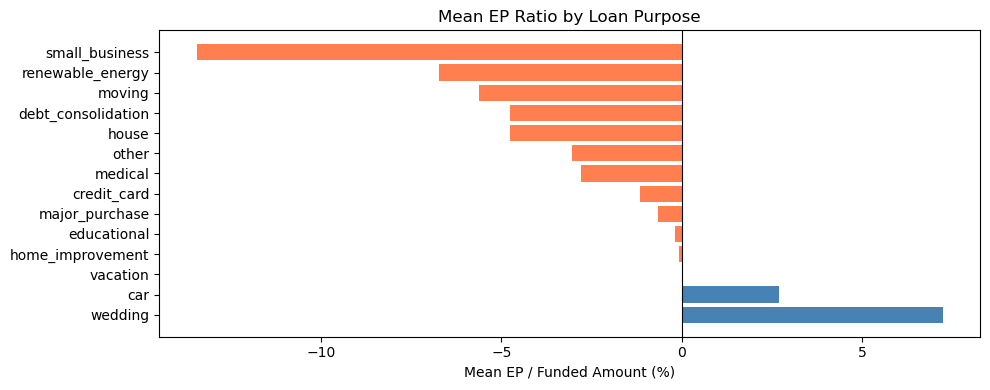

,purpose,n_loans,mean_int_rate,mean_ep_ratio,mean_el_ratio,pct_profitable
0,wedding,2294,14.1498,0.0724,0.2103,0.8339
1,car,14585,12.0766,0.0269,0.2058,0.6769
2,vacation,9065,13.7000,0.0003,0.2328,0.5520
3,home_improvement,87504,12.7921,-0.0007,0.2358,0.5783
4,educational,326,11.6505,-0.0020,0.2147,0.4877
5,major_purchase,29425,12.7352,-0.0066,0.2344,0.5615
6,credit_card,295279,11.7890,-0.0117,0.2271,0.5463
7,medical,15554,14.0129,-0.0280,0.2582,0.4598
8,other,77875,14.5888,-0.0304,0.2663,0.4544
9,house,7253,15.4191,-0.0476,0.2905,0.4262


In [9]:
purpose_summary = (
    df.groupby('purpose')
    .agg(
        n_loans       = ('funded_amnt',  'count'),
        mean_int_rate = ('int_rate',      'mean'),
        mean_ep_ratio = ('ep_ratio',      'mean'),
        mean_el_ratio = ('el_ratio',      'mean'),
        pct_profitable= ('ep',            lambda x: (x > 0).mean()),
    )
    .sort_values('mean_ep_ratio', ascending=False)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 4))
colors = ['steelblue' if v >= 0 else 'coral' for v in purpose_summary['mean_ep_ratio']]
ax.barh(purpose_summary['purpose'], purpose_summary['mean_ep_ratio'] * 100, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Mean EP / Funded Amount (%)')
ax.set_title('Mean EP Ratio by Loan Purpose')
plt.tight_layout()
plt.show()

display(purpose_summary.round(4))

### **By Vintage Year**

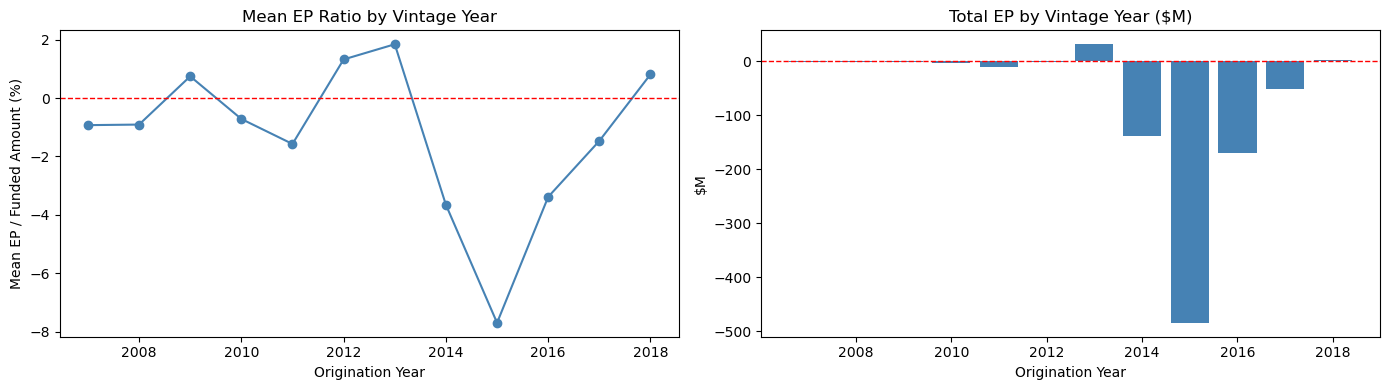

,issue_d_year,n_loans,mean_int_rate,mean_pd,mean_ep_ratio,mean_el_ratio,total_ep
0,2007,251,10.3153,0.3617,-0.0093,0.1995,"-75,527.9350"
1,2008,1562,11.1560,0.3823,-0.0091,0.2098,"-361,067.7720"
2,2009,4716,12.1898,0.3813,0.0075,0.2102,"-172,192.5881"
3,2010,11536,11.7489,0.4042,-0.0071,0.2348,"-2,320,923.0923"
4,2011,21721,12.2234,0.4190,-0.0157,0.2487,"-9,852,096.9080"
5,2012,53367,13.6378,0.4101,0.0132,0.2332,"-893,532.1520"
6,2013,134804,14.5316,0.4283,0.0184,0.2465,"31,943,215.8376"
7,2014,223102,13.6563,0.4590,-0.0366,0.2677,"-137,613,249.2751"
8,2015,375545,12.3852,0.4691,-0.0770,0.2746,"-484,407,647.0208"
9,2016,293095,13.0866,0.4426,-0.0338,0.2542,"-168,901,568.3543"


In [10]:
vintage_summary = (
    df.groupby('issue_d_year')
    .agg(
        n_loans       = ('funded_amnt',  'count'),
        mean_int_rate = ('int_rate',      'mean'),
        mean_pd       = ('pd_score',      'mean'),
        mean_ep_ratio = ('ep_ratio',      'mean'),
        mean_el_ratio = ('el_ratio',      'mean'),
        total_ep      = ('ep',            'sum'),
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(vintage_summary['issue_d_year'], vintage_summary['mean_ep_ratio'] * 100,
             'o-', color='steelblue')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_title('Mean EP Ratio by Vintage Year')
axes[0].set_xlabel('Origination Year')
axes[0].set_ylabel('Mean EP / Funded Amount (%)')

axes[1].bar(vintage_summary['issue_d_year'], vintage_summary['total_ep'] / 1e6, color='steelblue')
axes[1].axhline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_title('Total EP by Vintage Year ($M)')
axes[1].set_xlabel('Origination Year')
axes[1].set_ylabel('$M')

plt.tight_layout()
plt.show()

display(vintage_summary.round(4))

## **Break-Even Analysis**

For a given interest rate, there is a maximum PD the loan can carry before it becomes unprofitable. Setting EP = 0 and solving:

$$0 = (1 - \text{PD}) \cdot \text{Income} - \text{PD} \cdot \text{LGD} \cdot \text{EAD}$$

$$\text{PD}^* = \frac{\text{Income}}{\text{Income} + \text{LGD} \cdot \text{EAD}}$$

For a fixed LGD and EAD ratio, higher interest rates shift PD\* upward — meaning more credit risk can be tolerated before the loan destroys value. This gives a **break-even PD by rate** that can serve as a rate-sensitive approval cutoff.

I compute PD\* for each loan using its actual predicted LGD and EAD, then compare it to the actual predicted PD. Loans where `PD > PD*` are expected to be loss-making.

In [11]:
# Break-even PD per loan (using actual predicted LGD and EAD ratio)
# EP = 0 → PD* = income / (income + LGD * EAD)
df['pd_breakeven'] = df['income'] / (
    df['income'] + df['lgd_hat'] * df['ead_hat'] + 1e-9
)

# Margin of safety: how far the actual PD is from the break-even
df['pd_margin'] = df['pd_breakeven'] - df['pd_score']  # positive = safe, negative = loss-making

print(f'Loans above break-even PD (loss-making): {(df["pd_margin"] < 0).sum():,}'
      f'  ({(df["pd_margin"] < 0).mean():.1%})')
print(f'Mean PD margin (positive = safe)        : {df["pd_margin"].mean():.4f}')
print(f'Mean break-even PD across portfolio     : {df["pd_breakeven"].mean():.2%}')
print(f'Mean actual PD across portfolio         : {df["pd_score"].mean():.2%}')

Loans above break-even PD (loss-making): 724,377  (53.8%)
Mean PD margin (positive = safe)        : -0.0141
Mean break-even PD across portfolio     : 43.33%
Mean actual PD across portfolio         : 44.74%


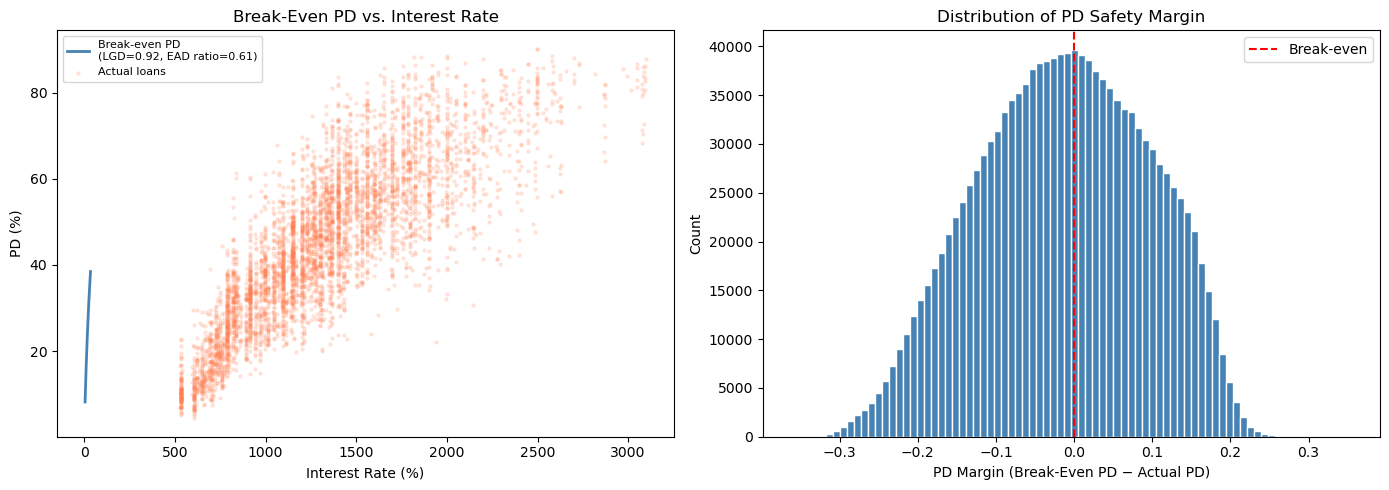

In [12]:
# Break-even PD curve as a function of int_rate
# Using portfolio mean LGD and EAD ratio as constants
mean_lgd = df['lgd_hat'].mean()
mean_ead = df['ead_ratio_hat'].mean()

rate_range = np.linspace(0.05, 0.35, 200)  # already in fraction form (5%-35%)
pd_star    = rate_range / (rate_range + mean_lgd * mean_ead + 1e-9)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Break-even curve
axes[0].plot(rate_range * 100, pd_star * 100, color='steelblue', linewidth=2,
             label=f'Break-even PD\n(LGD={mean_lgd:.2f}, EAD ratio={mean_ead:.2f})')
axes[0].scatter(df.sample(5000, random_state=42)['int_rate'] * 100,
                df.sample(5000, random_state=42)['pd_score'] * 100,
                alpha=0.15, s=5, color='coral', label='Actual loans')
axes[0].set_xlabel('Interest Rate (%)')
axes[0].set_ylabel('PD (%)')
axes[0].set_title('Break-Even PD vs. Interest Rate')
axes[0].legend(fontsize=8)

# Distribution of PD margin
axes[1].hist(df['pd_margin'], bins=80, color='steelblue', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Break-even')
axes[1].set_xlabel('PD Margin (Break-Even PD − Actual PD)')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of PD Safety Margin')
axes[1].legend()

plt.tight_layout()
plt.show()

## **Risk-Return Frontier**

The classic risk-return trade-off for credit: each grade sits at a different point in the EL ratio vs. EP ratio space. A well-priced portfolio should show compensation increasing with risk — higher EL grades should also have higher EP ratios. If a grade has high EL but low EP, it is mispriced (rate is insufficient to cover the risk).

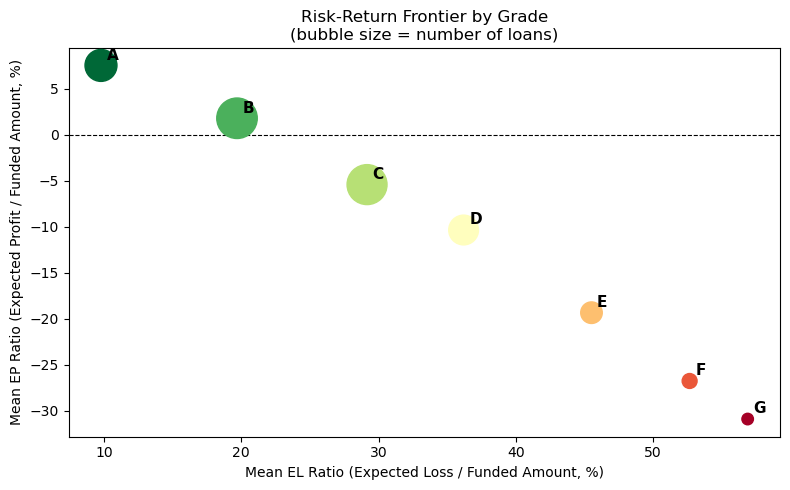

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))

sc = ax.scatter(
    grade_summary['mean_el_ratio'] * 100,
    grade_summary['mean_ep_ratio'] * 100,
    s=grade_summary['n_loans'] / grade_summary['n_loans'].max() * 800 + 50,
    c=range(len(grade_summary)),
    cmap='RdYlGn_r',
    zorder=3,
)

for _, row in grade_summary.iterrows():
    ax.annotate(
        str(row['grade_label']),
        xy=(row['mean_el_ratio'] * 100, row['mean_ep_ratio'] * 100),
        xytext=(4, 4), textcoords='offset points', fontsize=11, fontweight='bold'
    )

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Mean EL Ratio (Expected Loss / Funded Amount, %)')
ax.set_ylabel('Mean EP Ratio (Expected Profit / Funded Amount, %)')
ax.set_title('Risk-Return Frontier by Grade\n(bubble size = number of loans)')
plt.tight_layout()
plt.show()

## **Cutoff Simulation**

Tightening the PD cutoff removes the riskiest loans from the approved book. The question for EP is not just whether EL falls — we know it does — but whether the **removed loans were income-generating**. If we cut profitable high-rate loans, total EP may fall even as the EL ratio improves.

This simulation finds the EP-maximising cutoff, and also plots the full trade-off between total EP and approval rate.

In [14]:
cutoffs = np.linspace(0.05, 0.95, 150)

results = []
baseline_ep = df['ep'].sum()
baseline_el = df['el'].sum()

for c in cutoffs:
    approved = df[df['pd_score'] < c]
    if len(approved) == 0:
        continue
    results.append({
        'cutoff':        c,
        'approval_rate': len(approved) / len(df),
        'total_ep':      approved['ep'].sum(),
        'total_el':      approved['el'].sum(),
        'mean_ep_ratio': approved['ep_ratio'].mean(),
        'mean_el_ratio': approved['el_ratio'].mean(),
        'mean_pd':       approved['pd_score'].mean(),
        'pct_profitable':( approved['ep'] > 0).mean(),
    })

sim = pd.DataFrame(results)

# Find EP-maximising cutoff
best_idx    = sim['total_ep'].idxmax()
best_cutoff = sim.loc[best_idx, 'cutoff']
best_ep     = sim.loc[best_idx, 'total_ep']

print(f'EP-maximising PD cutoff : {best_cutoff:.3f}')
print(f'Max total EP            : ${best_ep:,.0f}')
print(f'Approval rate at max EP : {sim.loc[best_idx, "approval_rate"]:.1%}')
print(f'Baseline total EP (no cutoff): ${baseline_ep:,.0f}')

EP-maximising PD cutoff : 0.443
Max total EP            : $519,204,313
Approval rate at max EP : 49.0%
Baseline total EP (no cutoff): $-820,440,221


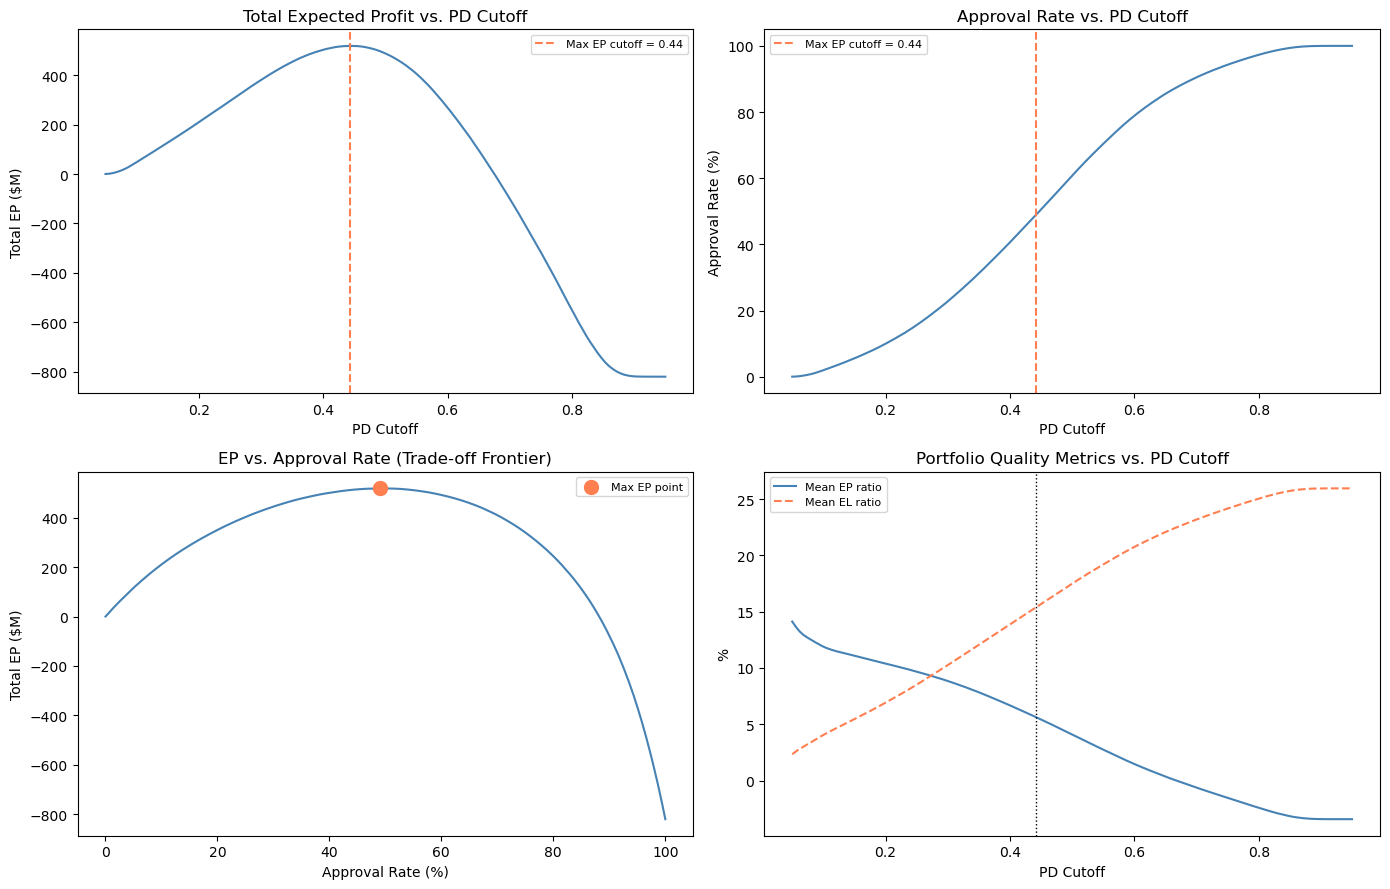

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Total EP vs cutoff
axes[0, 0].plot(sim['cutoff'], sim['total_ep'] / 1e6, color='steelblue')
axes[0, 0].axvline(best_cutoff, color='coral', linestyle='--',
                    label=f'Max EP cutoff = {best_cutoff:.2f}')
axes[0, 0].set_title('Total Expected Profit vs. PD Cutoff')
axes[0, 0].set_xlabel('PD Cutoff')
axes[0, 0].set_ylabel('Total EP ($M)')
axes[0, 0].legend(fontsize=8)

# Approval rate vs cutoff
axes[0, 1].plot(sim['cutoff'], sim['approval_rate'] * 100, color='steelblue')
axes[0, 1].axvline(best_cutoff, color='coral', linestyle='--',
                    label=f'Max EP cutoff = {best_cutoff:.2f}')
axes[0, 1].set_title('Approval Rate vs. PD Cutoff')
axes[0, 1].set_xlabel('PD Cutoff')
axes[0, 1].set_ylabel('Approval Rate (%)')
axes[0, 1].legend(fontsize=8)

# EP-Approval trade-off frontier
axes[1, 0].plot(sim['approval_rate'] * 100, sim['total_ep'] / 1e6, color='steelblue')
axes[1, 0].scatter(
    sim.loc[best_idx, 'approval_rate'] * 100,
    best_ep / 1e6,
    color='coral', s=100, zorder=5, label=f'Max EP point'
)
axes[1, 0].set_title('EP vs. Approval Rate (Trade-off Frontier)')
axes[1, 0].set_xlabel('Approval Rate (%)')
axes[1, 0].set_ylabel('Total EP ($M)')
axes[1, 0].legend(fontsize=8)

# EL ratio vs mean EP ratio (quality of approved book)
axes[1, 1].plot(sim['cutoff'], sim['mean_ep_ratio'] * 100, color='steelblue', label='Mean EP ratio')
axes[1, 1].plot(sim['cutoff'], sim['mean_el_ratio'] * 100, color='coral',
                linestyle='--', label='Mean EL ratio')
axes[1, 1].axvline(best_cutoff, color='black', linestyle=':', linewidth=1)
axes[1, 1].set_title('Portfolio Quality Metrics vs. PD Cutoff')
axes[1, 1].set_xlabel('PD Cutoff')
axes[1, 1].set_ylabel('%')
axes[1, 1].legend(fontsize=8)

plt.tight_layout()
plt.show()

In [16]:
# Reference table at key cutoffs
ref_cutoffs = [0.10, 0.15, 0.20, best_cutoff.round(2), 0.30, 0.40, 0.50]
ref_cutoffs = sorted(set(ref_cutoffs))
ref = sim[sim['cutoff'].apply(lambda x: any(abs(x - c) < 0.005 for c in ref_cutoffs))]
ref = ref.drop_duplicates(subset=['cutoff']).copy()
ref['total_ep_M'] = ref['total_ep'] / 1e6
ref['total_el_M'] = ref['total_el'] / 1e6
display(ref[['cutoff', 'approval_rate', 'mean_pd', 'mean_ep_ratio',
             'mean_el_ratio', 'total_ep_M', 'total_el_M', 'pct_profitable']].round(4).to_string(index=False))

' cutoff  approval_rate  mean_pd  mean_ep_ratio  mean_el_ratio  total_ep_M  total_el_M  pct_profitable\n 0.0983         0.0185   0.0807         0.1193         0.0399     45.6310     15.2520          1.0000\n 0.1044         0.0226   0.0844         0.1178         0.0418     55.0420     19.4384          1.0000\n 0.1466         0.0529   0.1082         0.1113         0.0536    122.2372     57.9181          1.0000\n 0.1527         0.0577   0.1117         0.1104         0.0553    131.8811     64.8498          1.0000\n 0.2010         0.1007   0.1399         0.1037         0.0694    212.0629    138.1185          1.0000\n 0.2977         0.2240   0.2021         0.0888         0.1016    377.1305    409.9545          0.9975\n 0.3037         0.2335   0.2062         0.0877         0.1038    387.0431    434.2174          0.9968\n 0.4003         0.4068   0.2689         0.0666         0.1387    503.6137    970.9884          0.9213\n 0.4366         0.4782   0.2913         0.0577         0.1518    518.624

## **Scenario Stress Test**

Same PD multipliers as the EL notebook (1.5×, 2.0×, 3.0×), but now we also see the EP impact. Under stress, PD rises, which increases EL and simultaneously reduces the income earned on non-defaulting loans — both effects compress EP. The question is how quickly EP turns negative as the macro environment deteriorates.

In [17]:
scenarios = {
    'Base':     1.0,
    'Mild':     1.5,
    'Moderate': 2.0,
    'Severe':   3.0,
}

scenario_results = []
for scenario, mult in scenarios.items():
    stressed_pd = (df['pd_score'] * mult).clip(0, 1)
    stressed_ep = (1 - stressed_pd) * df['income'] - stressed_pd * df['lgd_hat'] * df['ead_hat']
    stressed_el = stressed_pd * df['lgd_hat'] * df['ead_hat']
    scenario_results.append({
        'Scenario':           scenario,
        'PD Multiplier':      mult,
        'Mean PD':            stressed_pd.mean(),
        'Total EP ($M)':      stressed_ep.sum() / 1e6,
        'Total EL ($M)':      stressed_el.sum() / 1e6,
        'Mean EP Ratio (%)':  (stressed_ep / df['funded_amnt']).mean() * 100,
        'EP Change vs Base (%)': (stressed_ep.sum() / df['ep'].sum() - 1) * 100,
        '% Loans Profitable': (stressed_ep > 0).mean() * 100,
    })

scenario_df = pd.DataFrame(scenario_results)
display(scenario_df.round(3))

,Scenario,PD Multiplier,Mean PD,Total EP ($M),Total EL ($M),Mean EP Ratio (%),EP Change vs Base (%),% Loans Profitable
0,Base,1.0000,0.4470,-820.4400,"5,349.6290",-3.4350,0.0000,46.1550
1,Mild,1.5000,0.6550,"-5,624.3030","7,752.3080",-26.3910,585.5230,12.9510
2,Moderate,2.0000,0.7920,"-8,072.6780","9,115.3080",-39.4990,883.9450,5.3520
3,Severe,3.0000,0.9090,"-9,775.4590","10,164.5310",-49.2910,"1,091.4890",1.2010


## **Export**

In [18]:
export_cols = [
    'funded_amnt', 'int_rate', 'term', 'grade_label', 'purpose',
    'issue_d_year', 'is_default',
    'pd_score', 'lgd_hat', 'ead_ratio_hat', 'ead_hat',
    'el', 'el_ratio',
    'income', 'ep', 'ep_ratio',
    'pd_breakeven', 'pd_margin',
]

df[export_cols].to_parquet('ep_results.parquet', index=False)
print(f'Exported ep_results.parquet — {len(df):,} rows')

grade_summary.to_csv('ep_by_grade.csv', index=False)
print('Exported ep_by_grade.csv')

sim.to_csv('ep_cutoff_simulation.csv', index=False)
print('Exported ep_cutoff_simulation.csv')

print(f'\nEP-maximising cutoff : {best_cutoff:.3f}')
print(f'Total EP at that cutoff: ${best_ep:,.0f}')

Exported ep_results.parquet — 1,345,310 rows
Exported ep_by_grade.csv
Exported ep_cutoff_simulation.csv

EP-maximising cutoff : 0.443
Total EP at that cutoff: $519,204,313
